# Task 3 Overview

-***The risk team has begun to look at the existing book of loans to see if more defaults should be expected in the future and, if so, what the expected loss will be. They have collected data on customers and now want to build a predictive model that can estimate the probability of default based on customer characteristics. A better estimate of the number of customers defaulting on their loan obligations will allow us to set aside sufficient capital to absorb that loss. They have decided to work with you in the QR team to help predict the possible losses due to the loans that would potentially default in the next year.***
- **The task is to build a credit risk model that estimates how likely a borrower is to default on a loan, and then use that probability to estimate the bank’s expected financial loss.**
- side note - **A FICO score is a three-digit number, typically ranging from \(300\) to \(850\), used by lenders to assess your creditworthiness and predict the likelihood you will repay a loan.**

In [62]:
#import neccessary libraries
import numpy as np
import pandas as pd
import xgboost as xgb
from xgboost import XGBClassifier, XGBRegressor
import xgboost
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [16]:
df = pd.read_csv('loan_data.csv')
df

,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
0,8153374,0,5221.545193,3915.471226,78039.38546,5,605,0
1,7442532,5,1958.928726,8228.752520,26648.43525,2,572,1
2,2256073,0,3363.009259,2027.830850,65866.71246,4,602,0
3,4885975,0,4766.648001,2501.730397,74356.88347,5,612,0
4,4700614,1,1345.827718,1768.826187,23448.32631,6,631,0
...,...,...,...,...,...,...,...,...
9995,3972488,0,3033.647103,2553.733144,42691.62787,5,697,0
9996,6184073,1,4146.239304,5458.163525,79969.50521,8,615,0
9997,6694516,2,3088.223727,4813.090925,38192.67591,5,596,0
9998,3942961,0,3288.901666,1043.099660,50929.37206,2,647,0


In [4]:
df.shape

(10000, 8)

In [5]:
df.head

<bound method NDFrame.head of       customer_id  credit_lines_outstanding  loan_amt_outstanding  \
0         8153374                         0           5221.545193   
1         7442532                         5           1958.928726   
2         2256073                         0           3363.009259   
3         4885975                         0           4766.648001   
4         4700614                         1           1345.827718   
...           ...                       ...                   ...   
9995      3972488                         0           3033.647103   
9996      6184073                         1           4146.239304   
9997      6694516                         2           3088.223727   
9998      3942961                         0           3288.901666   
9999      5533570                         1           1917.652480   

      total_debt_outstanding       income  years_employed  fico_score  default  
0                3915.471226  78039.38546               5   

In [7]:
print(df.isnull().sum())

customer_id                 0
credit_lines_outstanding    0
loan_amt_outstanding        0
total_debt_outstanding      0
income                      0
years_employed              0
fico_score                  0
default                     0
dtype: int64


**no null values found thankfully**

In [8]:
#trying to understand target distribution
print(df["default"].value_counts())
print(df["default"].value_counts(normalize=True) * 100)

default
0    8149
1    1851
Name: count, dtype: int64
default
0    81.49
1    18.51
Name: proportion, dtype: float64


In [10]:
#check for duplicate values
print(df.duplicated().sum())

0


**no duplicate values found**


In [12]:
#check for targeted distribution
print(df["default"].value_counts(normalize=True)*100)

default
0    81.49
1    18.51
Name: proportion, dtype: float64


**data is heavily imbalanced**

In [13]:
df.describe

<bound method NDFrame.describe of       customer_id  credit_lines_outstanding  loan_amt_outstanding  \
0         8153374                         0           5221.545193   
1         7442532                         5           1958.928726   
2         2256073                         0           3363.009259   
3         4885975                         0           4766.648001   
4         4700614                         1           1345.827718   
...           ...                       ...                   ...   
9995      3972488                         0           3033.647103   
9996      6184073                         1           4146.239304   
9997      6694516                         2           3088.223727   
9998      3942961                         0           3288.901666   
9999      5533570                         1           1917.652480   

      total_debt_outstanding       income  years_employed  fico_score  default  
0                3915.471226  78039.38546               

In [14]:
#we will drop customer id since it would not be required to predict the output loss
df.drop(columns=['customer_id'])

,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
0,0,5221.545193,3915.471226,78039.38546,5,605,0
1,5,1958.928726,8228.752520,26648.43525,2,572,1
2,0,3363.009259,2027.830850,65866.71246,4,602,0
3,0,4766.648001,2501.730397,74356.88347,5,612,0
4,1,1345.827718,1768.826187,23448.32631,6,631,0
...,...,...,...,...,...,...,...
9995,0,3033.647103,2553.733144,42691.62787,5,697,0
9996,1,4146.239304,5458.163525,79969.50521,8,615,0
9997,2,3088.223727,4813.090925,38192.67591,5,596,0
9998,0,3288.901666,1043.099660,50929.37206,2,647,0


array([[<Axes: title={'center': 'customer_id'}>,
        <Axes: title={'center': 'credit_lines_outstanding'}>,
        <Axes: title={'center': 'loan_amt_outstanding'}>],
       [<Axes: title={'center': 'total_debt_outstanding'}>,
        <Axes: title={'center': 'income'}>,
        <Axes: title={'center': 'years_employed'}>],
       [<Axes: title={'center': 'fico_score'}>,
        <Axes: title={'center': 'default'}>, <Axes: >]], dtype=object)

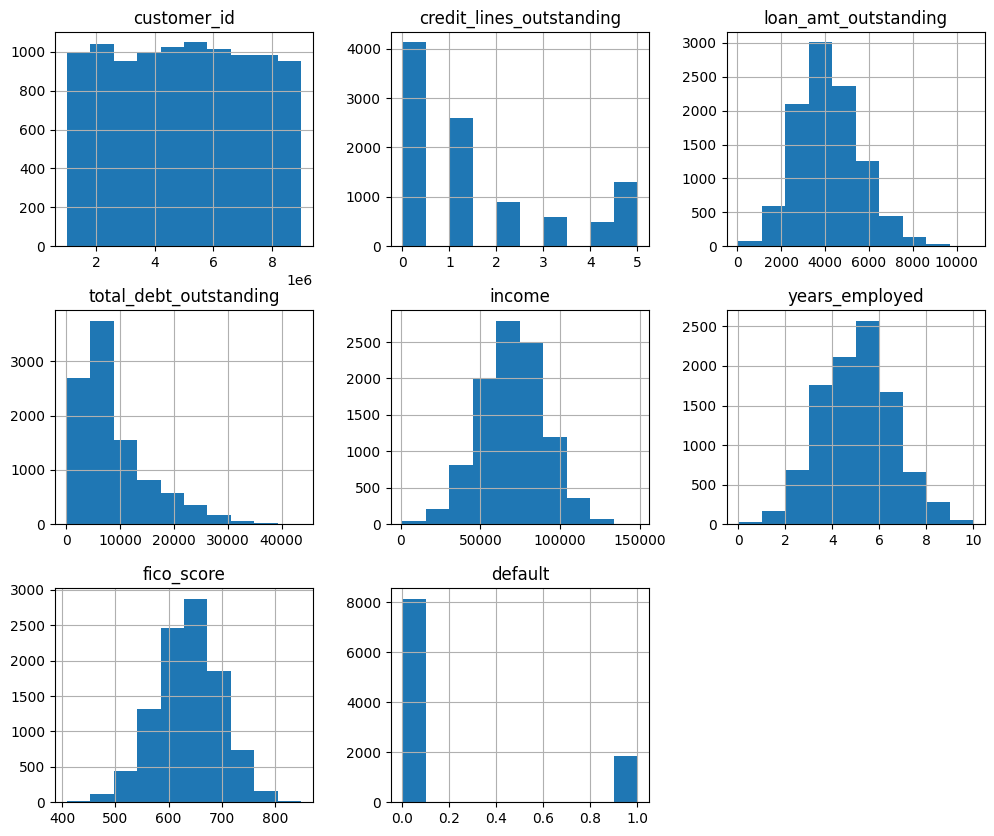

In [19]:
df.hist(figsize=(12,10))

**from the above data we can conclude the following:**
- loan_amt_outstanding is skewed to the left
- fico_score has a good bell shape
- total_debt_outstanding is highly skewed to the left


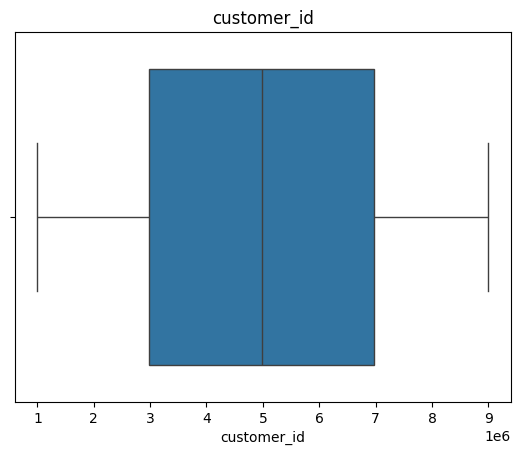

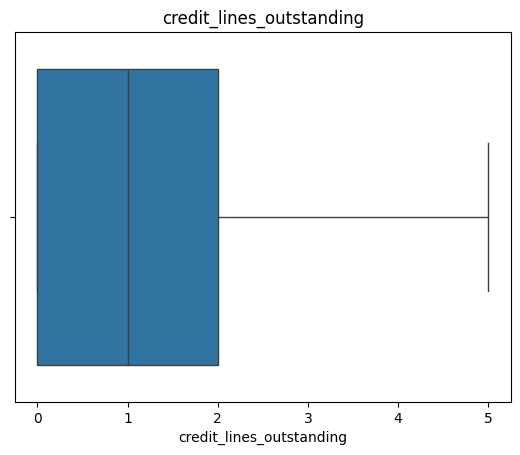

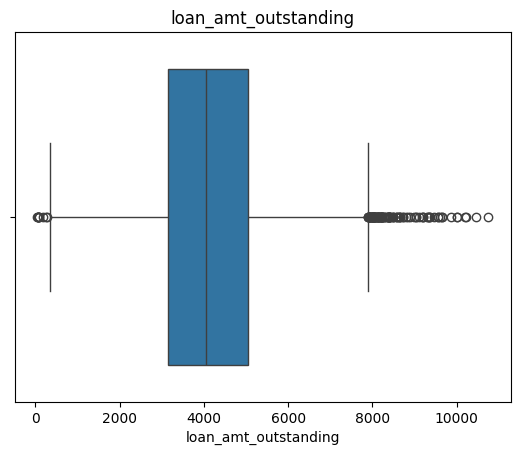

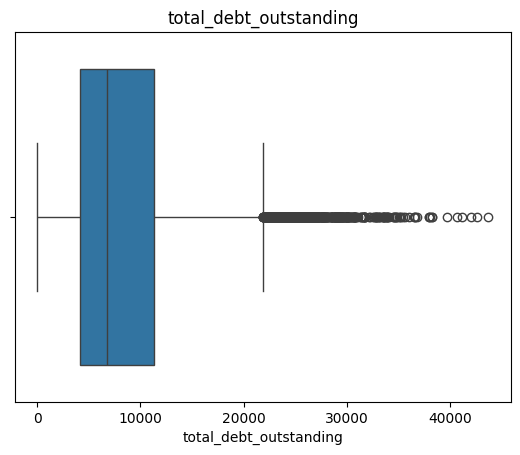

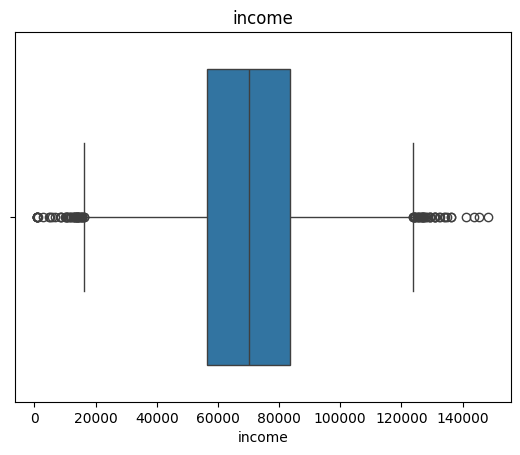

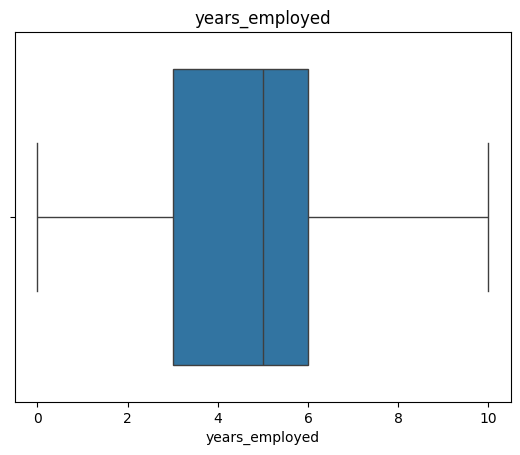

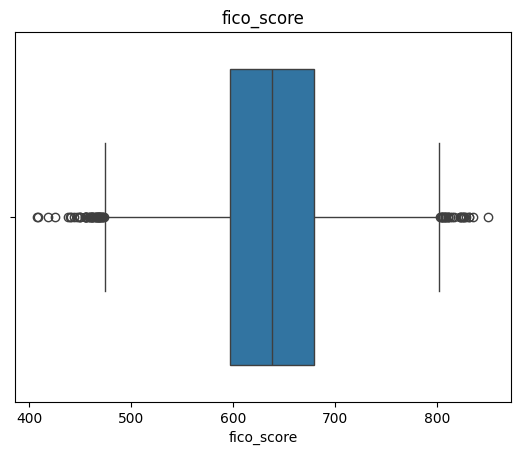

In [21]:
#detecting the outliers
for col in df.columns:
    if col != "default":
        sns.boxplot(x=df[col])
        plt.title(col)
        plt.show()

**from the above test we can say that the following are the features containing outliers:**
- loan_amt_outstanding (high numer of outliers, but can be considered normal considering the nature and purpose of the dataset)
- total_debt_outstanding (strongly right skewed)
- fico_score (shows signs of outliers but this feature is highly important for the prediction function, notable observation - high FICO score = safe and low FICO score = risky)

**we dont remove any features other than customer_id (not required to feed into the prediction function)**

data has many outliers, so we use XGBoost in order to deal with outliers properly.

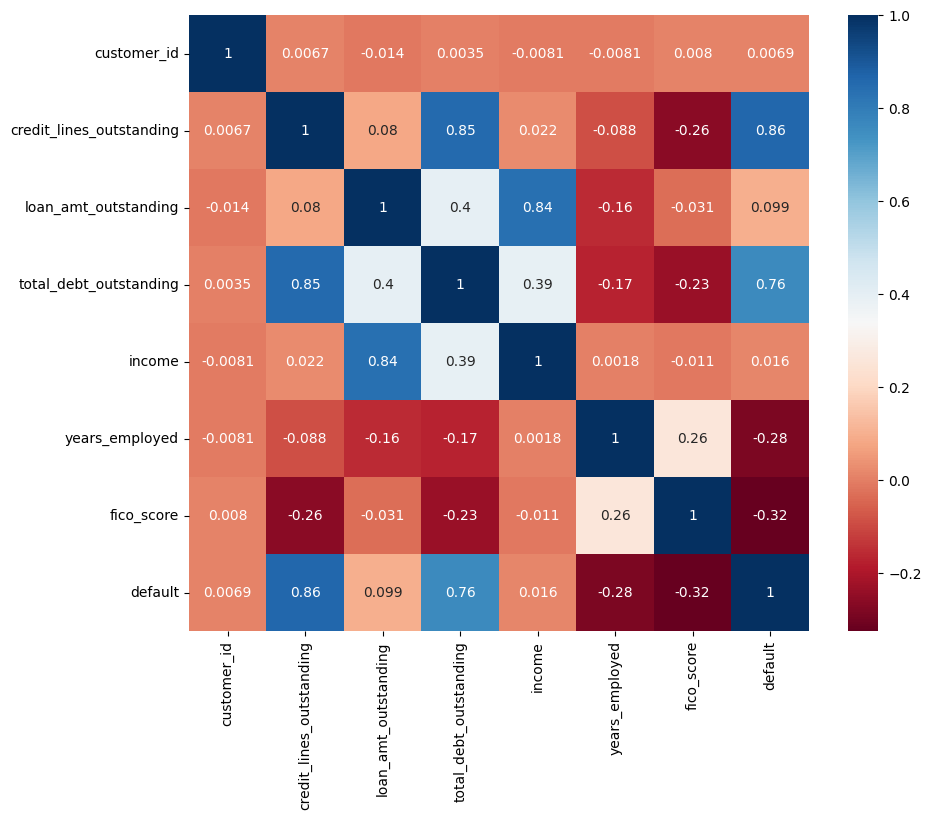

In [24]:
#correlation analysis using heatmaps
corr = df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="RdBu")
plt.show()

**from the heatmap we can conclude that higher debt and lower FICO scores are associated with increased default probability.**

In [30]:
#analyzing defaulters vs non-defaulters
print(df.groupby("default").mean())


          customer_id  credit_lines_outstanding  loan_amt_outstanding  \
default                                                                 
0        4.967005e+06                  0.744140           4092.629025   
1        5.007914e+06                  4.618044           4454.854897   

         total_debt_outstanding        income  years_employed  fico_score  
default                                                                    
0                   6322.164549  69883.889804        4.765247  646.938765  
1                  19270.582961  70726.740140        3.617504  596.257699  


**from the heatmap we observe that income vs loan_amt_outstanding has a relatively high postiive correlation, so we create a new feature space DTI_ratio (Debt to income ratio), this will help us better analyze the risk of credit. **

In [33]:
#creating a DTI ratio feature
df["dti_ratio"] = (df["total_debt_outstanding"] / df["income"])
df

,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default,dti_ratio
0,8153374,0,5221.545193,3915.471226,78039.38546,5,605,0,0.050173
1,7442532,5,1958.928726,8228.752520,26648.43525,2,572,1,0.308789
2,2256073,0,3363.009259,2027.830850,65866.71246,4,602,0,0.030787
3,4885975,0,4766.648001,2501.730397,74356.88347,5,612,0,0.033645
4,4700614,1,1345.827718,1768.826187,23448.32631,6,631,0,0.075435
...,...,...,...,...,...,...,...,...,...
9995,3972488,0,3033.647103,2553.733144,42691.62787,5,697,0,0.059818
9996,6184073,1,4146.239304,5458.163525,79969.50521,8,615,0,0.068253
9997,6694516,2,3088.223727,4813.090925,38192.67591,5,596,0,0.126021
9998,3942961,0,3288.901666,1043.099660,50929.37206,2,647,0,0.020481


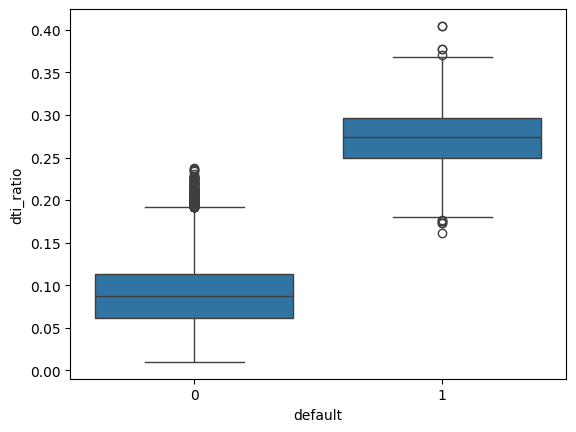

In [34]:
#analyzing the correlation of DTI ratio to default
sns.boxplot(x="default", y="dti_ratio", data=df)
plt.show()

boxplot shows a high dti to default ratio, having multiple outliers so we can conclude that higher PD shows higher repayment stress


In [36]:
#FICO band analysis
df["fico_band"] = pd.cut(
    df["fico_score"],
    bins=[300,580,670,740,800,850]
)

print(df.groupby("fico_band", observed = "False")["default"].mean())

fico_band
(300, 580]    0.430328
(580, 670]    0.171890
(670, 740]    0.073841
(740, 800]    0.028497
(800, 850]    0.032258
Name: default, dtype: float64


**we can observe and infer the following:**
- most of the people are in the [300,500] range
- fico score is highly predictable
  

In [37]:
df

,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default,dti_ratio,fico_band
0,8153374,0,5221.545193,3915.471226,78039.38546,5,605,0,0.050173,"(580, 670]"
1,7442532,5,1958.928726,8228.752520,26648.43525,2,572,1,0.308789,"(300, 580]"
2,2256073,0,3363.009259,2027.830850,65866.71246,4,602,0,0.030787,"(580, 670]"
3,4885975,0,4766.648001,2501.730397,74356.88347,5,612,0,0.033645,"(580, 670]"
4,4700614,1,1345.827718,1768.826187,23448.32631,6,631,0,0.075435,"(580, 670]"
...,...,...,...,...,...,...,...,...,...,...
9995,3972488,0,3033.647103,2553.733144,42691.62787,5,697,0,0.059818,"(670, 740]"
9996,6184073,1,4146.239304,5458.163525,79969.50521,8,615,0,0.068253,"(580, 670]"
9997,6694516,2,3088.223727,4813.090925,38192.67591,5,596,0,0.126021,"(580, 670]"
9998,3942961,0,3288.901666,1043.099660,50929.37206,2,647,0,0.020481,"(580, 670]"


In [42]:
#assigning data variables and splitting into train-test
df = df.drop(columns=["fico_band"]) #fixing datatype error caused during training
X = df.drop(columns=["default"])
y = df["default"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [57]:
#training and fitting XGBoost model
model = XGBClassifier(n_estimators=300, max_depth=5,learning_rate=0.05)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [70]:
#metrics analysis
pred_probs = model.predict_proba(X_test)[:,1]
print(roc_auc_score(y_test, pred_probs))
print(pred_probs)

0.9999602056043774
6.533e-06


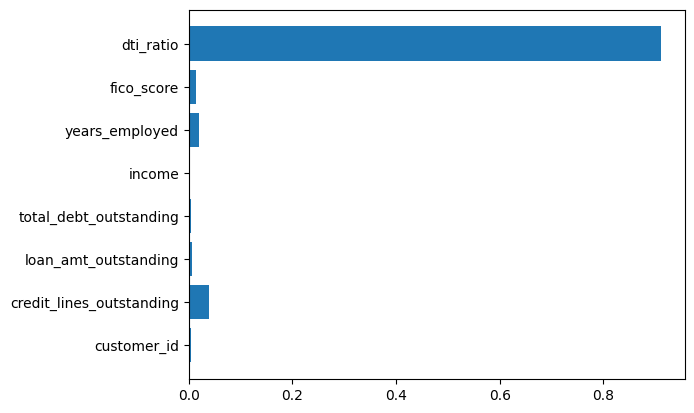

In [59]:
#analyzing feature importance
importance = model.feature_importances_
features = X.columns
plt.barh(features, importance)
plt.show()

# Logic behind the loss estimation function and some key credit risk concepts

## 1. Probability of Default (PD)

Probability of Default (PD) represents the likelihood that a borrower will fail to repay a loan.

The machine learning model predicts this probability using borrower financial information.

Example:

```text

PD = 0.20

```

This means the borrower has a 20% probability of defaulting.

The PD values are generated using:

```python

model.predict_proba(X)

```

which returns probabilities for both classes:

```python

[Probability of No Default, Probability of Default]

```

---

## 2. Loss Given Default (LGD)

Loss Given Default (LGD) represents the percentage of money the bank loses if the borrower defaults.

The assignment specifies:

```text

Recovery Rate = 10%

```

Therefore:

```text

LGD = 1 - Recovery Rate

     = 1 - 0.10

     = 0.90

```

Meaning:

- the bank recovers 10% of the money

- the bank loses 90% of the exposure

---

## 3. Exposure at Default (EAD)

Exposure at Default represents the amount of money exposed to risk when default occurs.

In this project:

```text

Loan Amount = Exposure

```

---

# Expected Loss Formula

The expected loss is calculated using:

```text

Expected Loss = PD × LGD × Loan Amount

```

Where:

- PD = Probability of Default

- LGD = Loss Given Default

- Loan Amount = Exposure

---



In [49]:
#calibrating probability function
calibrated_model = CalibratedClassifierCV(model, method="isotonic",cv=3)
calibrated_model.fit(X_train, y_train)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2","XGBClassifier...ree=None, ...)"
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'isotonic'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[fl

In [79]:
#loss function 
LGD = 0.90
def expected_loss(model, borrower_data, loan_amount):
    pd_value = float(model.predict_proba(borrower_data)[0][1])
    exp_loss = float(pd_value * LGD * loan_amount)
    return {
        "Probability_of_Default": pd_value,
        "Expected_Loss": round(exp_loss, 2)
    }

In [83]:
#example run

sample_borrower = X_test.iloc[[5]] #taking one borrower from the test set

# Loan amount
loan_amt = 92851

# Run function
result = expected_loss(model=model, borrower_data=sample_borrower, loan_amount=loan_amt)
print(result)

{'Probability_of_Default': 1.4322704373626038e-05, 'Expected_Loss': 1.2}


In [ ]:
#printing the metrics
print(')